# TALLER DE ANÁLISIS ESTADÍSTICO DE SEÑALES

### Presentado por: Alma Olea Barbosa - Lauren Cordero Ramos 

### Semestre 2026-2 

### IMPLEMENTACIÓN DE FUNCIONES

In [30]:
# importamos las librerias a utilizar
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.signal import find_peaks

In [4]:
# Función para calcular RMS
def RMS(N, x):
    suma = 0
    for i in range(N):
        suma += x[i]**2
    rms = np.sqrt(suma/N)
    return rms

### ANÁLISIS ESTADÍSTICO DE ECG

### PUNTO 1
Se determina el tiempo de duración de las señales y se crea un vector tiempo

In [23]:
# se cargan los archivos .mat
data = sio.loadmat('signals.mat') # el archivo tiene que estar en la misma carpeta
print(f"Contenido del archivo: {data}") # se imprime el contenido del archivo para identificar las variables almacenadas y su estructura

fs = int(data['Fs']) # extraer frecuencia de muestreo
print(f"\nFrecuencia de muestreo: {fs} Hz")

# se extraen las señales
# se usa .flatten() para convertir la matriz (1,N) en un solo vector de dim 1 y poder manejar más facil las muestras
señal_cruda = data['ECG_asRecording'].flatten()
señal_filt = data['ECG_filtered'].flatten()

N= len(señal_cruda) # Número de muestras
print(f"Número de muestras: {N}")

Ts= 1/fs #periodo de muestreo
duracion = N*Ts # duración de la señal en seg
print(f"Duración de la señal: {duracion} segundos")

#se crea el vector tiempo
t = np.arange(0, duracion, Ts)


Contenido del archivo: {'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Mon Apr 20 15:20:29 2015', '__version__': '1.0', '__globals__': [], 'Fs': array([[1024]], dtype=uint16), 'ECG_asRecording': array([[3904.31689453, 3939.203125  , 3976.00683594, ..., 4366.41064453,
        4365.31103516, 4370.91796875]]), 'ECG_filtered': array([[ 8.87103896e-03,  5.62737497e+01,  8.57077127e+01, ...,
        -1.20952610e+02, -1.31734356e+02, -1.32898021e+02]]), 'EMG_filtered1': array([[ 17.65905117,  19.41391578,  18.89666666, ..., 242.49414224,
        220.4135886 , 151.5810508 ]]), 'EMG_filtered2': array([[  21.1780547 ,  -79.82418538, -133.65960989, ..., -384.58994036,
        -539.9349533 , -772.65519631]]), 'EMG_asRecording1': array([[ 908.07531738,  903.17706299,  896.62982178, ..., 1433.91882324,
        1416.109375  , 1352.75012207]]), 'EMG_asRecording2': array([[-3109.97558594, -3231.01391602, -3302.34960938, ...,
        -3791.24267578, -3924.6550293 , -4109.94433594]])

### PUNTO 2

Graficar cruda vs. filtrada, compararlas y explicar qué tipo de filtro se usó

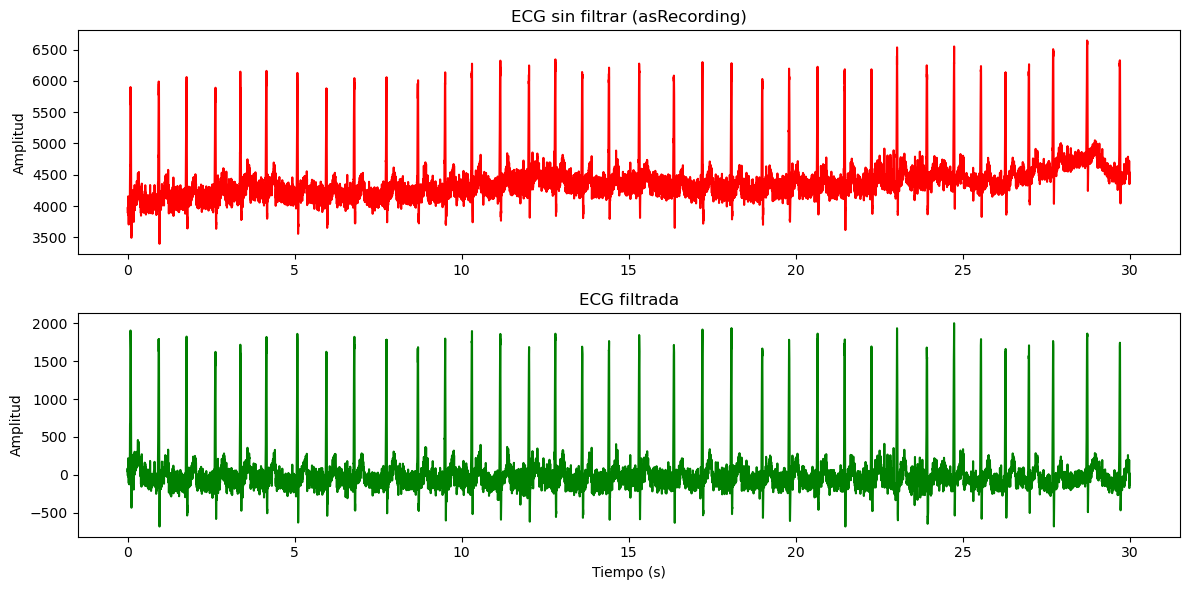

In [29]:
# Se grafica la señal
fig, axs = plt.subplots(2,1, figsize=(12,6))
axs[0].plot(t, señal_cruda, color='red')
axs[0].set_title('ECG sin filtrar (asRecording)')
axs[0].set_ylabel('Amplitud')
axs[1].plot(t, señal_filt, color='green')
axs[1].set_title('ECG filtrada')
axs[1].set_xlabel('Tiempo (s)')
axs[1].set_ylabel('Amplitud')
plt.tight_layout()

En la señal sin filtar se observa que la línea base no es constante, ya que empieza cerca de 4000-4500, se mantiene relativamente estable hasta el segundo 10 y luego sube progresivamente hasta llegar a 4500-5000. Tambien vemos que los picos (latidos) varían un poco en altura a lo largo del registro, al inicio llegan a ~6000 y hacia el final algunos alcanzan ~6500. 

Por otro lado, la señal filtrada su línea base se mantiene estable en 0 durante los 30 segundos completos y la amplitud de los latidos es más uniforme a lo largo de todo el registro (entre ~1600-2000), con esto podemos decir que el filtro eliminó componentes de muy baja frecuencia asociadas a artefactos como el movimiento del sujeto, la respiración o cambios de impedancia en los electrodos, y no a información fisiológica del corazón.Ademas, se observa que los picos (latidos) aparecen exactamente en los mismos instantes de tiempo que en la señal sin filtrar, es decir que tienen el mismo número de latidos y mismo ritmo, esto indica que el filtro no alteró el ritmo cardiaco ni distorsionó la ocurrencia de los latidos.

Con base en estas observaciones, se puede inferir que el filtro utilizado corresponde a un filtro pasa-altas con frecuencia de corte baja (posiblemente cercana a 0.5 Hz), cuyo objetivo es remover el offset DC y la deriva de línea base, conservando las frecuencias de interés del ECG (aproximadamente entre 0.5 Hz y 40-150 Hz, donde se concentran las ondas P, QRS y T) (Wesolowski et al., 2023).

#### PUNTO 3

Tomar la señal cruda, graficar un ciclo cardiaco (un latido), y calcular su promedio, RMS, varianza y desviación estándar.

Nota: Este punto se puede hacer de dos maneras: una opción es al 'ojo', es decir, elegir dónde empieza un ciclo y dónde termina el otro, mientras que otra forma es usar la función find_peaks() para detectar los picos  R y asi poder identidicar con mayor precisión cada ciclo. 
Para esta segunda opción, la función find_peaks() se debe aplicar a la señal filtrada, ya que es más limpia por lo que se puede identificar los picos R sin confundirlo con ruido 

Número de picos detectados: 36


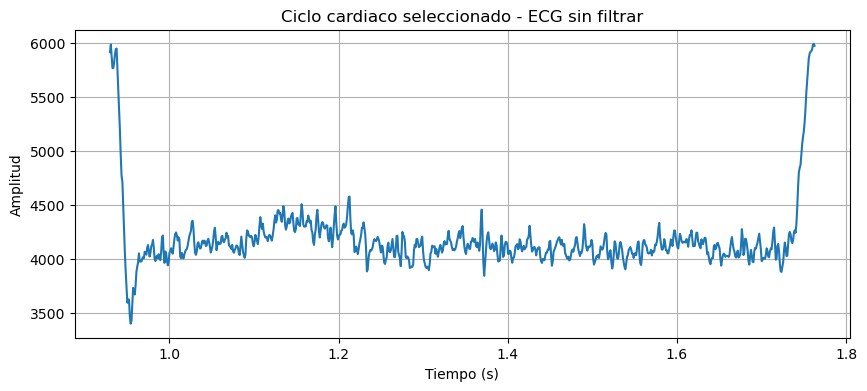

In [52]:
# Buscamos los picos R en la señal filtrada (es más limpia, mejor para detectar)
# height=800 -> solo cuenta picos con amplitud mayor a 800 para evitar que tome picos equivocados
# distance=0.4*Fs -> los picos deben estar separados al menos 0.4 segundos (un corazón normal no late más rápido que cada 0.4s, o sea, max 150 lpm)
picos, _ = find_peaks(señal_filt, height=800, distance=int(0.4*fs))

print("Número de picos detectados:", len(picos))

# Tomamos el ciclo entre el segundo pico y el tercero
inicio = picos[1]
fin = picos[2]

t_ciclo = t[inicio:fin] # instante de tiempo donde empieza y termina el ciclo que selecionamos
ciclo_sinfiltrar = señal_cruda[inicio:fin] # instante donde empieza y termina la señal

# Graficamos
plt.figure(figsize=(10,4))
plt.plot(t_ciclo, ciclo_sinfiltrar)
plt.title('Ciclo cardiaco seleccionado - ECG sin filtrar')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

#### PUNTO 4

Repetir lo mismo con la señal filtrada

#### PUNTO 5

Extraer 15 ciclos de la señal filtrada, calcular promedio y varianza de cada uno, graficarlos todos, evaluar si parecen estadísticamente similares y analizar si se puede considerar como una señal estacionaria

#### PUNTO 6

Comparar dos pares de ciclos con prueba t, pero antes verificando los supuestos:
Normalidad (ej. Shapiro-Wilk)
Independencia (se asume)
Homocedasticidad (prueba de Levene)
Si no se cumplen los supuestos, usar la alternativa no paramétrica: U de Mann-Whitney.

#### PUNTO 7

Confirmar la estacionariedad con la prueba de Dickey-Fuller

#### CONCLUSIONES

#### REFERENCIAS

Wesolowski, A., Zheng, D., & Nowak, A. (2023). Exploring Best Practices for ECG Pre-Processing in Machine Learning. arXiv preprint arXiv:2311.04229.